In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax
from glass import Glass
np.random.seed(1024)

## Generate some example data

In [2]:
n_channel, n_Tz = (10, 50)
n = 2000 # number of replication
K = 5 # how may categories
# simulate EEG signals
X = np.random.normal(size=(n, K, n_channel, n_Tz), scale=10)
# set channel weights, should be a unit vector, channels after the third one are noise channels. 
channel_weights = np.array([0.3, 0.4, -0.5] + [0 for _ in range(n_channel-3)])*np.sqrt(2)
# define the true latent channel time varying effects
beta = np.concatenate([np.zeros(10), np.sin(np.linspace(0, 2*np.pi, 20)), np.zeros(n_Tz-30)])*0.1
# compute latent channel EEG signals
X_latent = np.tensordot(X, channel_weights, [2, 0])
# generate labels
logodds = np.tensordot(X_latent, beta, [2, 0])
y = np.array([np.random.multinomial(1, softmax(logodd)) for logodd in logodds])
# use the first half of the data to train the model, and the other half as testing set. 
n_train = round(0.5*n)

## Usage of the code

Simply create the class, process the data (this step will define TFP models for the following computation), and run the mfvb algorithm (for parameter estimation). 

In [3]:
# Create the model class
model = Glass(shrinkage_factor=0.05)
# Create the model and link the data
model.process_data(X[:n_train], y[:n_train])
# Run the real computation
model.mfvb(1000)

We can plot the estimated and true latent channel time-varying effects like this. The estimation is quite accurate. 

Text(0, 0.5, 'Latent Channel Effect')

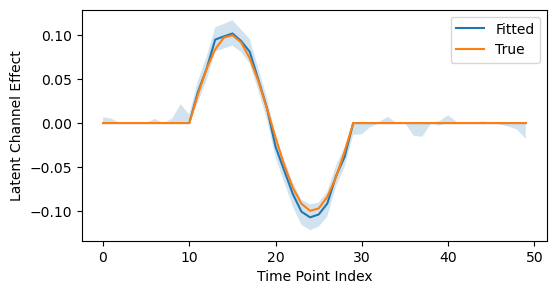

In [4]:
fig, ax = plt.subplots(figsize=(6, 3))
lb, ub = np.quantile(model.betagMats, axis=0, q = [0.025, 0.975])
ax.plot(model.betagMat.flatten(), label = 'Fitted')
ax.plot(beta, label = 'True')
ax.fill_between(np.arange(n_Tz), lb.flatten(), ub.flatten(), alpha=0.2)
ax.legend()
ax.set_xlabel('Time Point Index'); ax.set_ylabel('Latent Channel Effect')

Visualize channel weights

Text(0, 0.5, 'Channel Weight')

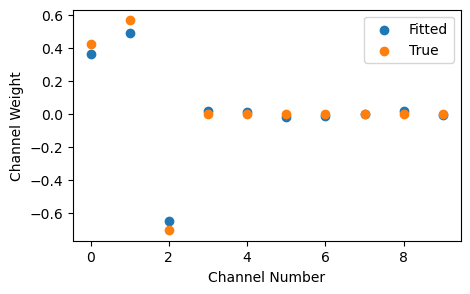

In [5]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(np.arange(n_channel), model.effective_weight.flatten(), label = 'Fitted')
ax.scatter(np.arange(n_channel), channel_weights, label = 'True')
ax.legend()
ax.set_xlabel('Channel Number'); ax.set_ylabel('Channel Weight')

We test the prediction accuracy of the model using testing data. Remember this accuracy is on the half-sequence level, which is not cummulated over multiple sequences as in real applications. 

In [6]:
# use the predict_prob func to get predicted probabilities of being the target
probs = model.predict_prob(X)
# evaluate the prediction accuracy
correct = np.take_along_axis(y[n_train:], probs.argmax(axis=1)[n_train:, None], axis=1).flatten()
'Testing accuracy: {:.2%}'.format(np.mean(correct))

'Testing accuracy: 75.20%'